Ce notebook permet de calculer les dommages en utilisant les expériences réalisées, la fonction de dommages emanuel_2011 et le fichier Litpop retraité (par Denisa ?), puis en appliquant les ratios de correction provenant de Ruben. 

Il faudrait refaire les calculs en partant des fichiers Litpop originaux (tels que téléchargés depuis le site).

In [ ]:
import pandas as pd
from pathlib import Path
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.dataset as ds
import pyarrow.compute as pc
import pyarrow.csv as pv
import pyarrow as pa
import numpy as np
import polars as pl
import geopandas as gpd
import reverse_geocode
from src.damages.damage_functions import emanuel_2011
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import tarfile
import io
import tomllib
import os

import geopandas as gpd
from shapely.geometry import Point
from shapely.prepared import prep
import matplotlib.pyplot as plt
import contextily as ctx
import matplotlib.colors as mcolors

import gc

from scipy.spatial import cKDTree
from pyproj import Transformer
import psutil

from multiprocessing import Process

## Données litpop (Denisa ?)

In [8]:
litpop_dir = Path("data/input/wealth_densities/litpop/5 minutes")
litpop = pd.concat([pd.read_hdf(fpath) for fpath in litpop_dir.glob("*.hdf5")], axis=0,ignore_index=True)
litpop = gpd.GeoDataFrame(litpop, geometry="geometry", crs="EPSG:4326")

In [9]:
litpop.shape

(297776, 6)

Ajout du pays

In [10]:
# Pays du monde
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

# Jointure spatiale
litpop_with_country = gpd.sjoin(
    litpop,
    world[["NAME", "geometry"]],
    how="left",
    predicate="within"
)

litpop_with_country.rename(columns={"NAME": "country"}, inplace=True)

# Comptage par pays
litpop_with_country["country"].value_counts()

country
United States of America    159108
China                       136004
Russia                         158
Canada                         145
Kazakhstan                      96
Mongolia                        94
India                           85
Nepal                           76
Myanmar                         56
North Korea                     52
Pakistan                        46
Vietnam                         45
Mexico                          20
Afghanistan                     17
Tajikistan                      14
Kyrgyzstan                      11
Bhutan                           7
Laos                             1
Name: count, dtype: int64

In [11]:
litpop_with_country.head()

,value,latitude,longitude,geometry,region_id,impf_,index_right,country
0,0.0,51.375,-178.958333,POINT (-178.95833 51.375),840,1,NaN,NaN
1,0.0,51.875,-178.208333,POINT (-178.20833 51.875),840,1,NaN,NaN
2,0.0,51.875,-178.125000,POINT (-178.125 51.875),840,1,NaN,NaN
3,0.0,51.875,-178.041667,POINT (-178.04167 51.875),840,1,NaN,NaN
4,0.0,51.875,-177.958333,POINT (-177.95833 51.875),840,1,NaN,NaN


In [12]:
litpop_with_country.groupby("country")["value"].sum().sort_values(ascending=False)
# que usa chine et quelques points chez leurs voisins !

country
United States of America    7.631615e+13
China                       3.892458e+13
Canada                      3.344525e+10
Vietnam                     1.469970e+09
Mexico                      1.398046e+09
Kazakhstan                  7.496313e+08
North Korea                 2.363025e+08
Russia                      1.648173e+08
Myanmar                     1.013447e+08
Nepal                       9.097176e+06
India                       7.820104e+06
Mongolia                    2.235111e+06
Pakistan                    1.998279e+06
Bhutan                      8.002225e+05
Kyrgyzstan                  5.563185e+05
Afghanistan                 4.138003e+05
Laos                        2.677707e+05
Tajikistan                  1.772119e+05
Name: value, dtype: float64

In [13]:
model = "ACCESS-CM2"
experiment = "ssp585"

output_dir = Path(f"./data/output/damages/national/{model}/{experiment}")
tracks_dir = Path(f"data/output/catherina/intensified_tracks/{model}/{experiment}")

In [14]:
tracks_ds = ds.dataset(tracks_dir, partitioning="hive")

Jointure des tracks avec les données litpop 

In [22]:
# On crée en output un fichier par année, donc avec tous les seeds mélangés : il faudra faire un groupby

transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:3857",
    always_xy=True,
)

# ------------------------------------------------------------------
# LitPop
# ------------------------------------------------------------------

lit_x, lit_y = transformer.transform(
    litpop_with_country.geometry.x.values,
    litpop_with_country.geometry.y.values,
)

lit_coords = np.column_stack(
    (lit_x, lit_y)
).astype(np.float32)

tree = cKDTree(lit_coords)

lit_val = litpop_with_country["value"].to_numpy(
    dtype=np.float32
)

lit_country = (
    litpop_with_country["country"]
    .fillna("Unknown")
    .astype(str)
    .to_numpy()
)


def mem():
    return psutil.Process(
        os.getpid()
    ).memory_info().rss / 1e9


def process_year(
    year,
    tracks_ds,
    tree,
    lit_val,
    lit_country,
):

    print(f"\n===== YEAR {year} =====")
    print(f"[START RAM] {mem():.2f} GB")

    table = tracks_ds.to_table(
        filter=(ds.field("year") == year),
        columns=[
            "seed",          
            "month",
            "lat_left",
            "lon_left",
            "final_wind_speed",
        ],
    )

    n = table.num_rows

    print(f"[ROWS] {n:,}")

    if n == 0:
        return

    seed = table.column("seed").to_numpy()

    lat = table.column("lat_left").to_numpy()
    lon = table.column("lon_left").to_numpy()
    wind = table.column("final_wind_speed").to_numpy()
    month = table.column("month").to_numpy()

    x, y = transformer.transform(lon, lat)

    coords = np.column_stack(
        (x, y)
    ).astype(
        np.float32,
        copy=False,
    )

    _, idx = tree.query(
        coords,
        k=1,
        workers=-1,
    )

    value = lit_val[idx]
    country = lit_country[idx]

    rel = emanuel_2011(wind)
    loss = rel * value

    output_file = output_dir / f"year={year}.parquet"

    output_file.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    pq.write_table(
        pa.table(
            {
                "year": np.full(
                    n,
                    year,
                    dtype=np.int32,
                ),
                "seed": seed,      # <-- conservé
                "month": month,
                "lat_left": lat,
                "lon_left": lon,
                "final_wind_speed": wind,
                "country": country,
                "value": value,
                "relative_losses": rel,
                "losses": loss,
            }
        ),
        output_file,
        compression="zstd",
    )

    print(f"[END RAM] {mem():.2f} GB")

    del (
        table,
        seed,
        lat,
        lon,
        wind,
        month,
        coords,
        idx,
        value,
        country,
        rel,
        loss,
    )

    gc.collect()


def run_all_years(
    years,
    tracks_ds,
    tree,
    lit_val,
    lit_country,
):

    for year in years:

        p = Process(
            target=process_year,
            args=(
                year,
                tracks_ds,
                tree,
                lit_val,
                lit_country,
            ),
        )

        p.start()
        p.join()


run_all_years(
    range(2025, 2100),
    tracks_ds,
    tree,
    lit_val,
    lit_country,
)


===== YEAR 2025 =====
[START RAM] 8.94 GB
[ROWS] 396,471


/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(


[END RAM] 9.36 GB

===== YEAR 2026 =====
[START RAM] 8.94 GB
[ROWS] 697,477


/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(


[END RAM] 9.57 GB

===== YEAR 2027 =====
[START RAM] 8.94 GB
[ROWS] 689,571


...

[END RAM] 6.50 GB

===== YEAR 2098 =====
[START RAM] 5.77 GB
[ROWS] 871,846


/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(


[END RAM] 6.39 GB

===== YEAR 2099 =====
[START RAM] 5.74 GB
[ROWS] 873,982


/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(


[END RAM] 6.33 GB


In [23]:
# Aggregate
all_losses = pl.read_parquet(output_dir / "*.parquet").to_pandas()

In [24]:
all_losses_grouped = all_losses.groupby(["year", "country", "seed"]).agg({"losses": "sum"})

In [ ]:
all_losses_grouped.to_parquet(output_dir / "")

In [ ]:
all_losses_grouped = all_losses_grouped.reset_index()
means = all_losses_grouped[all_losses_grouped.country == "United States of America"].groupby(["year", "country"])["losses"].mean().values

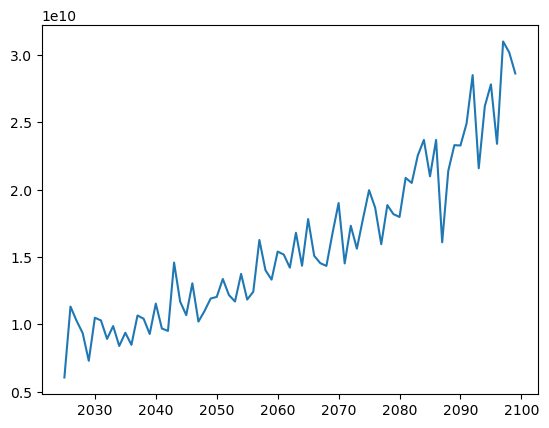

In [36]:
plt.plot(range(2025, 2100), means)

## Ajout ratio de correction

In [46]:
all_losses.head()

,year,lat_left,lon_left,final_wind_speed,index_right,value,latitude,longitude,region_id,impf_,relative_losses,losses,seed,SID,step,country_code,country
0,2025,12.500484,-106.500000,NaN,160051,8.355823e+08,26.375,-98.875,840,1,NaN,NaN,0,2119282752,0,MX,Mexico
1,2025,12.461908,-106.572353,20.010991,160051,8.355823e+08,26.375,-98.875,840,1,0.0,0.0,0,2119282752,1,MX,Mexico
2,2025,12.434372,-106.662559,18.364960,160051,8.355823e+08,26.375,-98.875,840,1,0.0,0.0,0,2119282752,2,MX,Mexico
3,2025,12.417464,-106.769879,15.390588,160051,8.355823e+08,26.375,-98.875,840,1,0.0,0.0,0,2119282752,3,MX,Mexico
4,2025,12.410696,-106.893604,16.206913,160051,8.355823e+08,26.375,-98.875,840,1,0.0,0.0,0,2119282752,4,MX,Mexico


In [62]:
ratio = pd.read_csv("data/input/wealth_densities/ratio_correction/country_rmsf_corr.csv", sep=";")
ratio_US = float(ratio[ratio["iso3"] == "USA"]["correction"].values[0].replace(",", "."))

In [61]:
ratio_US

0.685299803

In [75]:
losses_to_plot_with_ratio = ratio_US * all_losses[
    all_losses.country_code == "US"
].groupby(
    ["year", "country", "seed"]
).agg({"losses": "sum"})

In [ ]:
losses_to_plot_with_ratio

losses
year country       seed              
2025 United States 0     6.430447e+08
                   3     4.420291e+05
                   4     2.278860e+08
                   5     5.706638e+03
                   6     3.018539e+08
...                               ...
2099 United States 70    6.207830e+07
                   71    2.065329e+09
                   72    5.464953e+09
                   73    2.636284e+09
                   74    2.849062e+09

[5610 rows x 1 columns]

In [69]:
losses_per_year_with_ratio_metrics = (
    losses_to_plot_with_ratio
    .groupby("year", as_index=False)
    .agg(
        mean_losses=("losses", "mean"), 
        p90_losses=("losses", lambda x: np.percentile(x, 90)),
        p95_losses=("losses", lambda x: np.percentile(x, 95))
    )
)

/tmp/ipykernel_19338/1010317352.py:4: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  .agg(


In [76]:
losses_per_year_with_ratio_metrics

,mean_losses,p90_losses,p95_losses
0,1.150244e+09,2.788104e+09,6.160416e+09
1,1.296989e+09,3.343780e+09,4.797199e+09
2,1.005131e+09,2.505729e+09,4.465711e+09
3,7.033361e+08,1.579924e+09,3.095465e+09
4,6.975441e+08,1.223585e+09,4.087053e+09
...,...,...,...
70,2.959833e+09,5.309377e+09,8.427014e+09
71,3.582708e+09,1.007010e+10,1.869918e+10
72,3.622434e+09,1.151520e+10,1.867139e+10
73,2.939651e+09,7.828492e+09,1.361740e+10


KeyError: 'year'

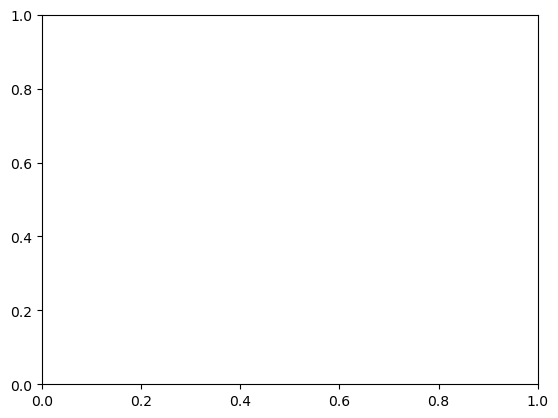

In [67]:
fig, ax = plt.subplots()
ax.plot(losses_per_year_with_ratio_metrics["year"], losses_per_year_with_ratio_metrics["mean_losses"]/1e9)
ax.plot(losses_per_year_with_ratio_metrics["year"], losses_per_year_with_ratio_metrics["p95_losses"]/1e9)
ax.plot(losses_per_year_with_ratio_metrics["year"], losses_per_year_with_ratio_metrics["p90_losses"]/1e9)
plt.xlabel("Year")
plt.ylabel("Mean annual losses (billion USD)")
plt.suptitle("Annual hurricane damages in the US")
plt.title("ACCESS-CM2 SSP5-8.5 scenario - Mean over 75 seeds")
plt.legend(["Mean losses", "95th percentile", "90th percentile"])
plt.grid()
plt.show()

## Calcul avec données litpop téléchargées directement

In [2]:
tracks_dir = Path("data/output/catherina/intensified_tracks/ACCESS-CM2/ssp585")
tracks_ds = ds.dataset(tracks_dir, partitioning="hive")

In [4]:
tracks_seed0 = tracks_ds.filter(ds.field("seed") == 0).to_table().to_pandas()

In [3]:
path_litpop = "data/input/wealth_densities/litpop/litpop_full/LitPop_v1_2.tar"
rows = []
# read the litpop data
with tarfile.open(path_litpop, "r") as tar:
    for member in tar:
        rows.append({
            "name": member.name,
            "size": member.size,
            "type": member.type,
            "mtime": member.mtime,
            "is_file": member.isfile(),
            "is_dir": member.isdir()
        })

litpop_df = pd.DataFrame(rows)

In [5]:
litpop_df

,name,size,type,mtime,is_file,is_dir
0,LitPop_v1_2,0,b'5',1586428289,False,True
1,LitPop_v1_2/LitPop_pc_30arcsec_LTU.csv,7432587,b'0',1551886059,True,False
2,LitPop_v1_2/LitPop_pc_30arcsec_BWA.csv,41742876,b'0',1551884465,True,False
3,LitPop_v1_2/LitPop_pc_30arcsec_IRQ.csv,33980358,b'0',1551885999,True,False
4,LitPop_v1_2/LitPop_pc_30arcsec_MHL.csv,8594,b'0',1551886078,True,False
...,...,...,...,...,...,...
225,LitPop_v1_2/LitPop_pc_30arcsec_TJK.csv,11541335,b'0',1551886521,True,False
226,LitPop_v1_2/LitPop_pc_30arcsec_PRI.csv,630059,b'0',1551886195,True,False
227,LitPop_v1_2/LitPop_pc_30arcsec_BMU.csv,5026,b'0',1551884449,True,False
228,LitPop_v1_2/LitPop_pc_30arcsec_GRD.csv,24189,b'0',1551885971,True,False


In [10]:
path_parquet_USA = "data/input/wealth_densities/litpop/litpop_full/LitPop_v1_2_USA.parquet"

with tarfile.open(path_litpop, "r:") as tar:
    member = tar.getmember("LitPop_v1_2/LitPop_pc_30arcsec_USA.csv")
    f = tar.extractfile(member)

    # Lecteur CSV en streaming
    csv_reader = pv.open_csv(
        f,
        read_options=pv.ReadOptions(block_size=1 << 20),  # ~1 MB par chunk
    )

    # Écriture Parquet incrémentale
    writer = None
    for next_batch in csv_reader:
        table = pa.Table.from_batches([next_batch])

        if writer is None:
            writer = pq.ParquetWriter(
                path_parquet_USA,
                table.schema,
                compression="snappy"
            )

        writer.write_table(table)

    if writer:
        writer.close()

In [11]:
df_usa = pl.read_parquet(path_parquet_USA)

In [17]:
df_usa["value"].sum()/10000000000000

5.5599336231102106

In [ ]:
# map des pays téléchargée
countries_path = "data/input/ne_10m_admin_0_countries.zip"
countries = gpd.read_file(countries_path, crs="EPSG:4326")

/home/tiphanie/projets_python/catherina/.pixi/envs/default/lib/python3.13/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver ESRI Shapefile does not support open option CRS
  return ogr_read(


In [35]:
countries = countries[["SOVEREIGNT", "SOV_A3", "geometry"]]

In [36]:
countries

,SOVEREIGNT,SOV_A3,geometry
0,Indonesia,IDN,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4..."
1,Malaysia,MYS,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4..."
2,Chile,CHL,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."
3,Bolivia,BOL,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5..."
4,Peru,PER,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832..."
...,...,...,...
253,China,CH1,"MULTIPOLYGON (((113.5586 22.16303, 113.56943 2..."
254,Australia,AU1,"POLYGON ((123.59702 -12.42832, 123.59775 -12.4..."
255,Bajo Nuevo Bank (Petrel Is.),BJN,"POLYGON ((-79.98929 15.79495, -79.98782 15.796..."
256,Serranilla Bank,SER,"POLYGON ((-78.63707 15.86209, -78.64041 15.864..."


In [37]:
map_usa = countries.loc[countries.SOVEREIGNT == 'United States of America', "geometry"].union_all()

In [40]:
countries.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [59]:
tracks_seeds = tracks_ds.filter(ds.field("seed").isin([0, 1, 2, 3, 4])).to_table().to_pandas()

In [63]:
geodf = gpd.GeoDataFrame(tracks_seeds, geometry=gpd.points_from_xy(tracks_seeds["lon_left"], tracks_seeds["lat_left"]), crs="EPSG:4326")


In [64]:
geodf.within(map_usa).sum()

np.int64(19850)

In [44]:
usa_res = []

for batch in tqdm(tracks_ds.to_batches(batch_size=1_000_000)):
    df = batch.to_pandas()
    tracks = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["lon_left"], df["lat_left"]), crs="EPSG:4326")
    tracks_in_usa = tracks.within(map_usa)
    usa_res.append(tracks_in_usa)


0it [00:00, ?it/s]

KeyboardInterrupt: 

In [ ]:
#TODO : mereg avec litpop, puis tous les seeds
# Test avec autres pays 
# Virer les 0 et créer un buffer ?
# Vérifier sur l'ancien code comment les merge sont faits : buffer ? quelle taille ? 